# Yearly TF-IDF ? `made_it_contract` Analysis

Capture per-year language summaries, dashboards for term shifts, and a single pipeline that trains on 2014-2021 (the only years with reliable second-contract labels) while projecting the model onto 2022-2025.


In [1]:
import re
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import average_precision_score
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

In [2]:
from pathlib import Path
ROOT = Path('..')  # repo root, relative to notebooks/
path = ROOT / 'data' / 'processed' / 'draft_enriched_with_contracts.csv'
raw = pd.read_csv(path, low_memory=False)
df = raw.query('2014 <= year <= 2025').copy()
text_cols = ['overview', 'strengths', 'weaknesses']
df[text_cols] = df[text_cols].fillna('')
df['scouting_text'] = (
    df[text_cols].agg(' '.join, axis=1)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)
numeric_cols = ['grade', 'total_score', 'production_score', 'athleticism_score']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
df['Pos_Group'] = df['Pos_Group'].fillna('UNKNOWN')
df['made_it_contract'] = df['made_it_contract'].where(df.year <= 2021)
df = df.loc[(df['grade'] > 0) & (df['scouting_text'].str.strip() != '')].copy()
tag_prefix = {'overview': 'OVR', 'strengths': 'STR', 'weaknesses': 'WKN'}
for col, prefix in tag_prefix.items():
    df[f'{col}_tagged'] = df[col].str.strip().replace('', pd.NA)
    df[f'{col}_tagged'] = df[f'{col}_tagged'].apply(lambda txt: f"{prefix}: {txt}" if pd.notna(txt) else '')

df['scouting_text_tagged'] = (
    df[[f'{col}_tagged' for col in text_cols]]
    .agg(' '.join, axis=1)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)


## NFL-Aware Preprocessing (no phrase stitching)

Use domain-curated stop words from `nfl_pre_proc.ipynb` — un-stopping directional adjectives
("high", "low", "deep") and removing scouting filler ("prospect", "ability") — but **without**
compound phrase stitching. TF-IDF bigrams via `ngram_range=(1,2)` capture collocations naturally;
stitched tokens like `pass_rush` would inflate IDF by appearing in only 10-20% of docs.

In [3]:
# ── NFL stopword config (from nfl_pre_proc.ipynb) ────────────────────────────
# Directional adjectives NLTK would stop that carry real scouting meaning
KEEP_WORDS = {
    'high', 'low', 'heavy', 'light', 'deep', 'short', 'long', 'wide',
    'hard', 'soft', 'strong', 'quick', 'good', 'great', 'up', 'down',
    'off', 'out', 'over', 'through', 'above', 'below',
}
# Generic scouting filler: appears in nearly every report, zero discriminative signal
CUSTOM_STOPS = {
    'prospect', 'player', 'players', 'show', 'shows', 'need', 'needs',
    'ability', 'also', 'often', 'must', 'well', 'still', 'use', 'get',
    'make', 'look', 'help', 'work', 'time', 'year', 'team', 'game',
    'continue', 'develop', 'development', 'nfl', 'draft', 'college',
    'level', 'type', 'project', 'potential', 'upside', 'ceiling',
}
# Outcome-leaking phrases stripped before any processing
PHRASE_BLOCKLIST = [
    'undrafted free agent', 'practice squad', 'free agent', 'early starter',
    'pro bowl', 'late round', 'undrafted free', 'make roster', 'rostered',
]
_base_stops = set(stopwords.words('english'))
NFL_STOPWORDS = (_base_stops - KEEP_WORDS) | CUSTOM_STOPS
_lemmatizer = WordNetLemmatizer()

print(f'NFL stop list: {len(NFL_STOPWORDS)} words '
      f'({len(KEEP_WORDS & _base_stops)} directionals un-stopped, {len(CUSTOM_STOPS)} filler added)')


def nfl_preprocess_no_stitch(text: str) -> str:
    """NFL-aware preprocessing without compound phrase stitching.

    Steps: lowercase → strip outcome-leaking phrases → normalize hyphens →
    alpha-only → tokenize → NFL stopwords → lemmatize.
    TF-IDF bigrams (ngram_range=(1,2)) capture collocations like 'pass rush'
    naturally without needing to stitch them into 'pass_rush' tokens.
    """
    if not isinstance(text, str) or not text.strip():
        return ''
    text = text.lower()
    for phrase in sorted(PHRASE_BLOCKLIST, key=len, reverse=True):
        text = text.replace(phrase, ' ')
    text = re.sub(r'[-\u2013\u2014]', ' ', text)   # normalize hyphens → space
    text = re.sub(r'[^a-z\s]', ' ', text)           # letters and spaces only
    tokens = text.split()
    tokens = [t for t in tokens if t not in NFL_STOPWORDS and len(t) > 1]
    tokens = [_lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)


# Apply preprocessing to each field independently, then rebuild scouting_text_tagged
_tag_prefix = {'overview': 'OVR', 'strengths': 'STR', 'weaknesses': 'WKN'}
for col, prefix in _tag_prefix.items():
    df[f'{col}_clean'] = df[col].apply(nfl_preprocess_no_stitch)

def _build_tagged_clean(row):
    parts = [f"{prefix}: {row[f'{col}_clean']}"
             for col, prefix in _tag_prefix.items()
             if str(row[f'{col}_clean']).strip()]
    return ' '.join(parts)

df['scouting_text_tagged'] = df.apply(_build_tagged_clean, axis=1)
df = df.loc[df['scouting_text_tagged'].str.strip() != ''].copy()

# Quick sanity checks
token_counts = df['scouting_text_tagged'].str.split().str.len()
print(f'Players after preprocessing: {len(df)}')
print(f'Tokens/player — median: {int(token_counts.median())}, '
      f'mean: {token_counts.mean():.0f}, '
      f'min: {token_counts.min()}, max: {token_counts.max()}')
print()
# Verify key directionals kept, filler removed
sample = df['scouting_text_tagged'].iloc[0]
print('Sample (first 300 chars):')
print(sample[:300])

NFL stop list: 225 words (8 directionals un-stopped, 35 filler added)
Players after preprocessing: 5321
Tokens/player — median: 133, mean: 135, min: 30, max: 392

Sample (first 300 chars):
OVR: physical specimen rare size speed combination clowney impactful junior playing through injury forced deal opposing offense fully accounted extra chip protection old junior affected turnover defensive coaching staff could benefit tremendously stable positional coach strong veteran mentor defensi


In [4]:
def compute_yearly_tfidf(subset, vectorizer=None, weight_col='total_score', norm='sum'):
    subset = subset[subset['scouting_text_tagged'].str.strip() != '']
    if subset.empty:
        return None
    if vectorizer is None:
        vectorizer = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=3, sublinear_tf=True)
    X = vectorizer.fit_transform(subset['scouting_text_tagged'])
    weights = subset[weight_col].fillna(1.0).clip(lower=1.0)
    weighted = X.multiply(weights.values[:, None])
    denom = weights.sum() if norm == 'sum' else len(weights)
    denom = max(denom, 1.0)
    agg = np.asarray(weighted.sum(axis=0)).ravel() / denom
    return {
        'year': subset['year'].iloc[0],
        'vectorizer': vectorizer,
        'weights': agg,
        'vocab': vectorizer.get_feature_names_out(),
        'denom': denom,
    }

In [5]:
# Updated params: lower max_features + min_df floor to remove hapax bigrams,
# sublinear_tf=True since docs are ~150-200 tokens (TF is nearly binary at this length).
# stop_words removed — handled upstream by nfl_preprocess_no_stitch.
vectorizer_params = dict(max_features=1000, ngram_range=(1, 2), min_df=3, sublinear_tf=True)
years = range(2014, 2026)
yearly_info = {}
for year in years:
    info = compute_yearly_tfidf(
        df[df.year == year],
        vectorizer=TfidfVectorizer(**vectorizer_params),
        weight_col='total_score',
        norm='sum',
    )
    if info:
        yearly_info[year] = info

top_rows = []
for year, info in yearly_info.items():
    agg = info['weights']
    idx = np.argsort(agg)[::-1][:12]
    for rank, term_idx in enumerate(idx, 1):
        top_rows.append({
            'year': year,
            'rank': rank,
            'term': info['vocab'][term_idx],
            'score': float(agg[term_idx]),
        })
top_terms_df = pd.DataFrame(top_rows)
top_terms_df

,year,rank,term,score
0,2014,1,good,0.046434
1,2014,2,play,0.042608
2,2014,3,run,0.039559
3,2014,4,hand,0.038395
4,2014,5,off,0.038174
...,...,...,...,...
139,2025,8,lack,0.040064
140,2025,9,good,0.040019
141,2025,10,speed,0.037807
142,2025,11,rush,0.036386


### Bigram highlights

Filter the per-year summaries for multi-word phrases so you can see which skill/value bigrams stand out each class.

In [6]:
bigram_rows = []
for year, info in yearly_info.items():
    vocab = info['vocab']
    weights = info['weights']
    bigram_idx = [i for i, term in enumerate(vocab) if ' ' in term]
    if not bigram_idx:
        continue
    top_bigrams = sorted(bigram_idx, key=lambda i: weights[i], reverse=True)[:8]
    for rank, idx in enumerate(top_bigrams, 1):
        bigram_rows.append({
            'year': year,
            'rank': rank,
            'bigram': vocab[idx],
            'score': float(weights[idx]),
        })
bigram_terms_df = pd.DataFrame(bigram_rows)
bigram_terms_df.sort_values(['year', 'rank']).head(20)


,year,rank,bigram,score
0,2014,1,special team,0.021846
1,2014,2,str good,0.020137
2,2014,3,could stand,0.019376
3,2014,4,lack ideal,0.018872
4,2014,5,tight end,0.016282
5,2014,6,wkn lack,0.015185
6,2014,7,body control,0.014777
7,2014,8,ovr big,0.014768
8,2015,1,pas rusher,0.022485
9,2015,2,running back,0.018244


In [7]:
pivot = top_terms_df.pivot(index='term', columns='year', values='score').fillna(0)
training_cols = [y for y in pivot.columns if 2014 <= y <= 2021]
if training_cols:
    baseline = pivot[training_cols].mean(axis=1)
else:
    baseline = pd.Series(0, index=pivot.index)
latest = pivot[2025] if 2025 in pivot.columns else pd.Series(0, index=pivot.index)
deltas = (latest - baseline).dropna().sort_values(ascending=False).head(10).reset_index(name='score_delta')
deltas


,term,score_delta
0,rush,0.036386
1,average,0.026302
2,catch,0.026033
3,lack,0.022069
4,good,0.020283
5,block,0.020058
6,route,0.009039
7,run,0.003941
8,hand,0.001816
9,play,0.000779


## Classifier pipeline

We train on 2014-2021 where `made_it_contract` labels exist, compare PR-AUC to a grade+position baseline, and then project the text model onto 2022-2025.


In [8]:
numeric_features = ['grade', 'total_score', 'production_score', 'athleticism_score', 'year']
cat_features = ['Pos_Group']

class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X[self.columns]

class YearNormalizedTfidf(BaseEstimator, TransformerMixin):
    def __init__(self, text_column='scouting_text', year_column='year', vectorizer_params=None):
        self.text_column = text_column
        self.year_column = year_column
        self.vectorizer_params = vectorizer_params or {}
        self.vectorizer = TfidfVectorizer(**self.vectorizer_params)

    def fit(self, X, y=None):
        texts = X[self.text_column].fillna('')
        years = X[self.year_column].astype(int).values
        tfidf = self.vectorizer.fit_transform(texts)
        arr = tfidf.toarray()
        self.year_means_ = {}
        for year in np.unique(years):
            mask = years == year
            if mask.sum():
                self.year_means_[year] = arr[mask].mean(axis=0)
        self.global_mean_ = arr.mean(axis=0)
        return self

    def transform(self, X):
        texts = X[self.text_column].fillna('')
        years = X[self.year_column].astype(int).values
        tfidf = self.vectorizer.transform(texts)
        arr = tfidf.toarray()
        adjusted = arr.copy()
        for year, mean in self.year_means_.items():
            mask = years == year
            if mask.sum():
                adjusted[mask] -= mean
        unseen_mask = ~np.isin(years, list(self.year_means_.keys()))
        if unseen_mask.any():
            adjusted[unseen_mask] -= self.global_mean_
        return adjusted

text_pipeline = Pipeline([
    ('selector', ColumnSelector(['scouting_text_tagged', 'year'])),
    ('year_norm', YearNormalizedTfidf(text_column='scouting_text_tagged', vectorizer_params=vectorizer_params)),
])

meta_transformer = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('pos', OneHotEncoder(handle_unknown='ignore'), cat_features),
    ],
    remainder='drop',
)

preprocessor = FeatureUnion([
    ('text', text_pipeline),
    ('meta', meta_transformer),
])

pipe = Pipeline([
    ('features', preprocessor),
    ('rf', RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=42, n_jobs=-1)),
])

baseline_preprocessor = ColumnTransformer(
    transformers=[
        ('grade', StandardScaler(), ['grade']),
        ('pos', OneHotEncoder(handle_unknown='ignore'), ['Pos_Group']),
        ('year', StandardScaler(), ['year']),
    ],
    remainder='drop',
)
baseline_pipe = Pipeline([
    ('preproc', baseline_preprocessor),
    ('lr', LogisticRegression(max_iter=2000, solver='liblinear')),
])

train_mask = df.year.between(2014, 2021) & df.made_it_contract.notna()
train_df = df.loc[train_mask].copy()
train_df['made_it_contract'] = train_df['made_it_contract'].astype(int)
y_train = train_df['made_it_contract']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

positive_rate = y_train.mean()
desired_rate = 0.3
if positive_rate in (0, 1):
    pos_weight = neg_weight = 1.0
else:
    pos_weight = desired_rate / positive_rate
    neg_weight = (1 - desired_rate) / (1 - positive_rate)
baseline_weights = y_train * pos_weight + (1 - y_train) * neg_weight

text_scores = cross_val_score(pipe, train_df, y_train, cv=cv, scoring='average_precision')
baseline_scores = []
for train_idx, test_idx in cv.split(train_df, y_train):
    estimator = clone(baseline_pipe)
    estimator.fit(train_df.iloc[train_idx], y_train.iloc[train_idx], lr__sample_weight=baseline_weights.iloc[train_idx])
    preds = estimator.predict_proba(train_df.iloc[test_idx])[:, 1]
    baseline_scores.append(average_precision_score(y_train.iloc[test_idx], preds))
baseline_scores = np.array(baseline_scores)

print("Text + scores + pos PR-AUC: %.3f +- %.3f" % (text_scores.mean(), text_scores.std()))
print("Calibrated grade + Pos_Group PR-AUC: %.3f +- %.3f" % (baseline_scores.mean(), baseline_scores.std()))


Text + scores + pos PR-AUC: 0.566 +- 0.021
Calibrated grade + Pos_Group PR-AUC: 0.567 +- 0.024


In [9]:
pipe.fit(train_df, y_train)
baseline_pipe.fit(train_df, y_train, lr__sample_weight=baseline_weights)

future_df = df[df.year.between(2022, 2025)].copy()
future_df['pred_made_it'] = pipe.predict_proba(future_df)[:, 1]
future_df['baseline_score'] = baseline_pipe.predict_proba(future_df)[:, 1]
cols = ['year', 'player_name', 'team', 'Pos_Group', 'grade', 'total_score', 'pred_made_it', 'baseline_score']
future_summary = future_df.sort_values(['pred_made_it'], ascending=False)[cols].head(12)
future_summary


,year,player_name,team,Pos_Group,grade,total_score,pred_made_it,baseline_score
5412,2022,Malik Willis,Tennessee Titans,QB,6.41,80.0,0.7550,0.503159
5863,2023,Bryce Young,Carolina Panthers,QB,6.82,90.0,0.7350,0.685601
6843,2025,Cam Ward,Tennessee Titans,QB,6.39,86.0,0.7125,0.472829
5396,2022,Evan Neal,New York Giants,OL,6.76,86.0,0.7125,0.718816
6355,2024,JC Latham,Tennessee Titans,OL,6.71,87.0,0.7100,0.687097
6350,2024,Caleb Williams,Chicago Bears,QB,6.74,92.0,0.6875,0.644979
6367,2024,Olumuyiwa Fashanu,New York Jets,OL,6.45,87.0,0.6825,0.570213
5435,2022,Daxton Hill,Cincinnati Bengals,DB,6.33,89.0,0.6750,0.456976
6359,2024,Joe Alt,Los Angeles Chargers,OL,6.49,97.0,0.6625,0.589098
6829,2025,Will Campbell,New England Patriots,OL,6.44,85.0,0.6600,0.558675


### Section-specific TF-IDF + tagged tokens

Compare a pipeline that fits year-normalized TF-IDF separately for each text field (overview/strengths/weaknesses) with a single-vectorizer approach that tags each token with its section prefix. Both keep the context while still working on short documents.

In [10]:
section_cols = ['overview_clean', 'strengths_clean', 'weaknesses_clean']
section_pipelines = []
section_vectorizer_params = dict(max_features=500, ngram_range=(1, 2), min_df=3, sublinear_tf=True)
for col in section_cols:
    section_pipelines.append((
        f'{col}_text',
        Pipeline([
            ('selector', ColumnSelector([col, 'year'])),
            ('year_norm', YearNormalizedTfidf(text_column=col, year_column='year', vectorizer_params=section_vectorizer_params)),
        ])
    ))
section_text_union = FeatureUnion(section_pipelines)
section_full_features = FeatureUnion([
    ('section_text', section_text_union),
    ('meta', meta_transformer),
])
section_pipe = Pipeline([
    ('features', section_full_features),
    ('rf', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)),
])
section_scores = cross_val_score(section_pipe, train_df, y_train, cv=cv, scoring='average_precision')

tagged_feature = ColumnTransformer(
    transformers=[
        ('text_tagged', TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=3, sublinear_tf=True), 'scouting_text_tagged'),
        ('num', StandardScaler(), numeric_features),
        ('pos', OneHotEncoder(handle_unknown='ignore'), cat_features),
    ],
    remainder='drop',
)
tagged_pipe = Pipeline([
    ('features', tagged_feature),
    ('rf', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)),
])
tagged_scores = cross_val_score(tagged_pipe, train_df, y_train, cv=cv, scoring='average_precision')

print('Section-specific TF-IDF PR-AUC: %.3f +- %.3f' % (section_scores.mean(), section_scores.std()))
print('Tagged tokens TF-IDF PR-AUC : %.3f +- %.3f' % (tagged_scores.mean(), tagged_scores.std()))

Section-specific TF-IDF PR-AUC: 0.555 +- 0.024
Tagged tokens TF-IDF PR-AUC : 0.557 +- 0.024


### Pos_Group-aware + rolling window modeling

Train group-specific pipelines for EDGE and DB, then blend the long-term model with a 2019-2021 rolling window to keep the probabilities fresh (a lightweight analogue of Bayesian updating on the latest language).

In [11]:
group_stats = []
pos_groups = ['EDGE', 'DB']
for group in pos_groups:
    subset = train_df[train_df['Pos_Group'] == group]
    if subset.empty:
        continue
    folds = min(4, max(2, subset.shape[0] // 25))
    group_cv = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)
    group_pipe = clone(pipe)
    scores = cross_val_score(group_pipe, subset, subset['made_it_contract'], cv=group_cv, scoring='average_precision')
    group_pipe.fit(subset, subset['made_it_contract'])
    group_stats.append({
        'Pos_Group': group,
        'rows': subset.shape[0],
        'mean_pr_auc': scores.mean(),
        'std_pr_auc': scores.std(),
    })

group_stats_df = pd.DataFrame(group_stats)
group_stats_df

rolling_df = train_df[train_df['year'] >= 2019]
rolling_splits = min(4, max(2, rolling_df.shape[0] // 25))
rolling_cv = StratifiedKFold(n_splits=rolling_splits, shuffle=True, random_state=42)
rolling_pipe = clone(pipe)
rolling_scores = cross_val_score(rolling_pipe, rolling_df, rolling_df['made_it_contract'], cv=rolling_cv, scoring='average_precision')
rolling_pipe.fit(rolling_df, rolling_df['made_it_contract'])
print('Rolling window (2019-2021) PR-AUC: %.3f +- %.3f' % (rolling_scores.mean(), rolling_scores.std()))

future_df['rolling_pred'] = rolling_pipe.predict_proba(future_df)[:, 1]
future_df['ensemble_pred'] = (future_df['pred_made_it'] + future_df['rolling_pred']) / 2
future_df['ensemble_delta'] = future_df['ensemble_pred'] - future_df['baseline_score']
cols = ['year', 'player_name', 'team', 'Pos_Group', 'grade', 'total_score', 'pred_made_it', 'baseline_score']
future_summary = future_df.sort_values('ensemble_pred', ascending=False)[cols + ['rolling_pred', 'ensemble_pred', 'ensemble_delta']].head(12)
future_summary

Rolling window (2019-2021) PR-AUC: 0.513 +- 0.030


,year,player_name,team,Pos_Group,grade,total_score,pred_made_it,baseline_score,rolling_pred,ensemble_pred,ensemble_delta
6843,2025,Cam Ward,Tennessee Titans,QB,6.39,86.0,0.7125,0.472829,0.7300,0.72125,0.248421
6355,2024,JC Latham,Tennessee Titans,OL,6.71,87.0,0.7100,0.687097,0.6850,0.69750,0.010403
5412,2022,Malik Willis,Tennessee Titans,QB,6.41,80.0,0.7550,0.503159,0.6350,0.69500,0.191841
6350,2024,Caleb Williams,Chicago Bears,QB,6.74,92.0,0.6875,0.644979,0.6925,0.69000,0.045021
5418,2022,Kenny Pickett,Pittsburgh Steelers,QB,6.40,84.0,0.6525,0.498314,0.7125,0.68250,0.184186
5863,2023,Bryce Young,Carolina Panthers,QB,6.82,90.0,0.7350,0.685601,0.6100,0.67250,-0.013101
5396,2022,Evan Neal,New York Giants,OL,6.76,86.0,0.7125,0.718816,0.6200,0.66625,-0.052566
6367,2024,Olumuyiwa Fashanu,New York Jets,OL,6.45,87.0,0.6825,0.570213,0.6125,0.64750,0.077287
5399,2022,Kayvon Thibodeaux,New York Giants,EDGE,6.72,86.0,0.6550,0.648615,0.6400,0.64750,-0.001115
6359,2024,Joe Alt,Los Angeles Chargers,OL,6.49,97.0,0.6625,0.589098,0.5975,0.63000,0.040902


## Backtest: where text outperforms grade+position

Look at the 2014-2021 positives where the text model raises the predicted probability well above the grade+Pos_Group baseline.

In [12]:

train_preds = train_df.copy()
train_preds['text_score'] = pipe.predict_proba(train_preds)[:, 1]
train_preds['baseline_score'] = baseline_pipe.predict_proba(train_preds)[:, 1]
train_preds['score_delta'] = train_preds['text_score'] - train_preds['baseline_score']
train_preds['rolling_pred'] = rolling_pipe.predict_proba(train_preds)[:, 1]
train_preds['ensemble_pred'] = (train_preds['text_score'] + train_preds['rolling_pred']) / 2
train_preds['ensemble_delta'] = train_preds['ensemble_pred'] - train_preds['baseline_score']

text_only_winners = train_preds[
    (train_preds['made_it_contract'] == 1) & 
    (train_preds['score_delta'] > 0) & 
    (train_preds['grade'] != 0)
].sort_values('grade', ascending=False)

print('Text > grade+pos positives:', len(text_only_winners))
text_only_winners.loc[:, ['year', 'player_name', 'Pos_Group', 'grade', 'text_score', 'baseline_score', 'ensemble_pred', 'ensemble_delta']].head(10)


Text > grade+pos positives: 988


,year,player_name,Pos_Group,grade,text_score,baseline_score,ensemble_pred,ensemble_delta
3271,2018,Saquon Barkley,RB,7.45,0.8825,0.872261,0.77500,-0.097261
2007,2015,Leonard Williams,EDGE,7.40,0.9000,0.893181,0.72375,-0.169431
4926,2021,Trevor Lawrence,QB,7.40,0.8775,0.876398,0.87625,-0.000148
3273,2018,Quenton Nelson,OL,7.40,0.9175,0.907970,0.78750,-0.120470
3272,2018,Bradley Chubb,EDGE,7.40,0.8925,0.885033,0.77625,-0.108783
4420,2020,Chase Young,EDGE,7.37,0.8900,0.872998,0.86125,-0.011748
4927,2021,Kyle Pitts,TE,7.19,0.8600,0.850067,0.85625,0.006183
4928,2021,DeVonta Smith,WR,7.13,0.7900,0.732219,0.80500,0.072781
4929,2021,Ja'Marr Chase,WR,7.12,0.7825,0.728402,0.78000,0.051598
4422,2020,Derrick Brown,DT,7.11,0.8500,0.813076,0.83250,0.019424


## Missed second-contract positives

Players that the baseline ranks at =30% but the text model raises above that cutoff even though they made a second contract.

In [13]:
missed_positive = train_preds.loc[
    (train_preds['made_it_contract'] == 1)
    & (train_preds['baseline_score'] <= 0.5)
    & (train_preds['text_score'] > 0.3)
    & (train_preds['grade'] > 0)
]


print('Text model rescues', len(missed_positive), 'positives that the baseline doubted')
selected_cols = ['year', 'player_name', 'Pos_Group', 'grade', 'text_score', 'baseline_score', 'score_delta']
missed_positive.sort_values('score_delta', ascending=False).loc[:, selected_cols].head(12)


Text model rescues 755 positives that the baseline doubted


,year,player_name,Pos_Group,grade,text_score,baseline_score,score_delta
1995,2014,Albert Wilson,WR,5.10,0.7350,0.060928,0.674072
1972,2014,Roosevelt Nix,RB,5.10,0.7475,0.074273,0.673227
1945,2014,Quincy Enunwa,WR,5.10,0.7300,0.060928,0.669072
2819,2016,Romeo Okwara,EDGE,5.10,0.7450,0.086183,0.658817
4294,2019,Ashton Dulin,WR,5.40,0.7425,0.091820,0.650680
1965,2014,Nevin Lawson,DB,5.10,0.7375,0.088206,0.649294
3722,2018,Mike Boone,RB,5.10,0.7150,0.067041,0.647959
1975,2014,Kevin Pierre-Louis,EDGE,5.10,0.7375,0.090623,0.646877
2367,2015,Jon Feliciano,OL,5.10,0.7525,0.110516,0.641984
4909,2020,Azur Kamara,EDGE,5.19,0.7300,0.091374,0.638626


## Model edge over time

Aggregate the probability delta by year so you can see whether the text model is gaining ground across draft classes.

In [14]:
yearly_edge = train_preds.groupby('year').agg(
    mean_delta=('score_delta', 'mean'),
    pct_delta_positive=('score_delta', lambda x: (x > 0).mean()),
    avg_text=('text_score', 'mean'),
    avg_baseline=('baseline_score', 'mean'),
).reset_index()
yearly_edge['pct_delta_positive'] = yearly_edge['pct_delta_positive'] * 100
yearly_edge


,year,mean_delta,pct_delta_positive,avg_text,avg_baseline
0,2014,0.042452,36.253041,0.315718,0.273266
1,2015,0.020813,36.746988,0.337191,0.316378
2,2016,-0.010881,32.080925,0.312608,0.323490
3,2017,0.011062,34.550562,0.336412,0.325350
4,2018,0.041453,35.000000,0.338685,0.297232
5,2019,0.020736,33.489461,0.314426,0.293690
6,2020,0.027161,33.174224,0.323699,0.296539
7,2021,0.029527,34.502924,0.345453,0.315926


## Tee Higgins text vs. baseline contributions + WR scatter plots

Explain what text features lift Tee Higgins and then plot grade vs. probability for all WRs to compare the baseline and text models.

Tee Higgins baseline cohort info: {'year': 2020, 'Pos_Group': 'WR', 'grade': 6.37}
Top text deviations for Tee Higgins:
cornerback      0.161287
adjustment      0.156538
stride          0.150200
press           0.124091
played          0.123219
press corner    0.122516
pluck           0.119036
dangerous       0.118562
dtype: float64
Baseline probability contributions (intercept -0.758):
grade__grade              1.006832
pos__Pos_Group_DB        -0.000000
pos__Pos_Group_DT        -0.000000
pos__Pos_Group_EDGE      -0.000000
pos__Pos_Group_LB         0.000000
pos__Pos_Group_OL         0.000000
pos__Pos_Group_QB        -0.000000
pos__Pos_Group_RB        -0.000000
pos__Pos_Group_SPECIAL    0.000000
pos__Pos_Group_TE        -0.000000
year__year               -0.067723
pos__Pos_Group_WR        -0.620416
dtype: float64


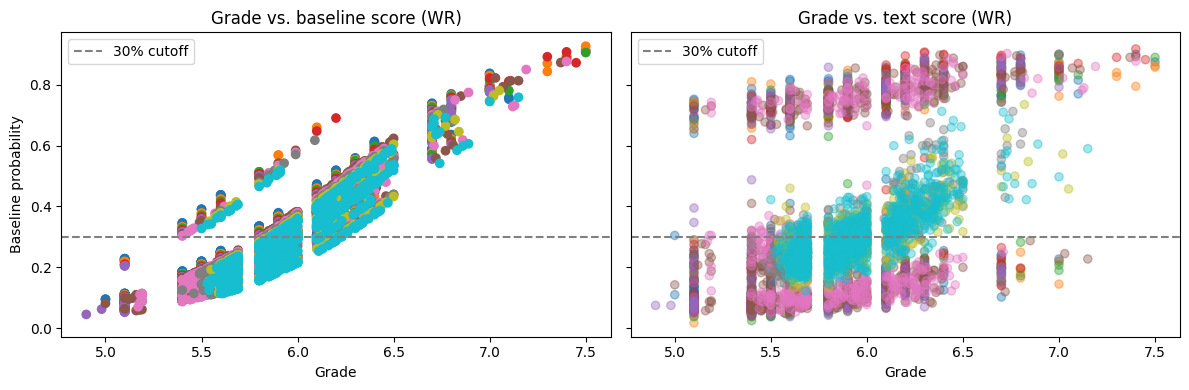

In [15]:
import matplotlib.pyplot as plt
tee_df = df[df['player_name'].str.contains('Tee Higgins', case=False)].head(1)
if tee_df.empty:
    raise ValueError('Could not find Tee Higgins in the dataset')
tee = tee_df
text_pipe = pipe.named_steps['features'].transformer_list[0][1]
year_norm = text_pipe.named_steps['year_norm']
text_terms = year_norm.vectorizer.get_feature_names_out()
tee_text = year_norm.transform(tee[['scouting_text_tagged', 'year']])
text_series = pd.Series(tee_text.ravel(), index=text_terms)
print('Tee Higgins baseline cohort info:', tee[['year', 'Pos_Group', 'grade']].to_dict(orient='records')[0])
print('Top text deviations for Tee Higgins:')
print(text_series.nlargest(8))

baseline_preproc = baseline_pipe.named_steps['preproc']
baseline_input = tee[['grade', 'Pos_Group', 'year']]
baseline_values = baseline_preproc.transform(baseline_input).toarray().ravel()
feature_names = baseline_preproc.get_feature_names_out()
coef = baseline_pipe.named_steps['lr'].coef_.ravel()
contrib = pd.Series(coef * baseline_values, index=feature_names)
print('Baseline probability contributions (intercept %.3f):' % baseline_pipe.named_steps['lr'].intercept_[0])
print(contrib.sort_values(ascending=False))

wr = df.copy()
wr = wr[wr['grade'] > 0]
wr['text_score'] = pipe.predict_proba(wr)[:, 1]
wr['baseline_score'] = baseline_pipe.predict_proba(wr)[:, 1]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].scatter(wr['grade'], wr['baseline_score'], c=wr['year'], cmap='tab10', alpha=1)
axes[0].set_title('Grade vs. baseline score (WR)')
axes[0].set_xlabel('Grade')
axes[0].set_ylabel('Baseline probability')
axes[0].axhline(0.3, color='gray', ls='--', label='30% cutoff')
axes[0].legend()
axes[1].scatter(wr['grade'], wr['text_score'],c=wr['year'], cmap='tab10', alpha=0.4, )
axes[1].set_title('Grade vs. text score (WR)')
axes[1].set_xlabel('Grade')
axes[1].axhline(0.3, color='gray', ls='--', label='30% cutoff')
axes[1].legend()
# Create a mappable that knows the range of your data
#sm = plt.cm.ScalarMappable(cmap='tab10', norm=plt.Normalize(vmin=wr['year'].min(), vmax=wr['year'].max()))
#fig.colorbar(sm, ax=axes, label='Year')
plt.tight_layout()

In [16]:
from matplotlib import lines

norm = plt.Normalize(wr['year'].min(), wr['year'].max())
cmap = plt.colormaps['tab10']
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

for ax, score, title in zip(
    axes,
    ['baseline_score', 'text_score'],
    ['Grade vs. baseline score (WR)', 'Grade vs. text score (WR)']
):
    ax.scatter(
        wr['grade'],
        wr[score],
        c=wr['year'],
        cmap=cmap,
        norm=norm,
        alpha=0.6
    )
    ax.set_title(title)
    ax.set_xlabel('Grade')
    if score == 'baseline_score':
        ax.set_ylabel('Baseline probability')
    ax.axhline(0.3, color='gray', ls='--')

year_handles = [
    lines.Line2D([0], [0], marker='o', linestyle='', color=cmap(norm(year)), label=str(year))
    for year in sorted(wr['year'].unique())
]
cutoff_handle = lines.Line2D([0], [0], color='gray', ls='--', label='30% cutoff')
axes[0].legend(handles=year_handles + [cutoff_handle], title='Year')
axes[1].legend(handles=[cutoff_handle])

fig.colorbar(sm, ax=axes.ravel().tolist(), label='Year')
plt.tight_layout()


<Figure size 640x480 with 0 Axes>

### Top residuals vs. baseline

Highlight the players where the text model (and the ensemble) deviates most from the grade+Pos_Group baseline so you can inspect what language it likes or dislikes.

In [17]:
residuals = train_preds.assign(
    residual=train_preds['text_score'] - train_preds['baseline_score'],
    ensemble_residual=train_preds['ensemble_pred'] - train_preds['baseline_score'],
)
top_positive = residuals.nlargest(8, 'residual')[['year', 'player_name', 'Pos_Group', 'grade', 'text_score', 'baseline_score', 'residual', 'ensemble_residual', 'made_it_contract']]
top_negative = residuals.nsmallest(8, 'residual')[['year', 'player_name', 'Pos_Group', 'grade', 'text_score', 'baseline_score', 'residual', 'ensemble_residual', 'made_it_contract']]
print('Top text > baseline residuals:')
print(top_positive.to_string(index=False))
print('Top text << baseline (neg residuals):')
print(top_negative.to_string(index=False))

Top text > baseline residuals:
 year        player_name Pos_Group  grade  text_score  baseline_score  residual  ensemble_residual  made_it_contract
 2014      Albert Wilson        WR    5.1      0.7350        0.060928  0.674072           0.457822                 1
 2014      Roosevelt Nix        RB    5.1      0.7475        0.074273  0.673227           0.450727                 1
 2014      Quincy Enunwa        WR    5.1      0.7300        0.060928  0.669072           0.490322                 1
 2016       Romeo Okwara      EDGE    5.1      0.7450        0.086183  0.658817           0.427567                 1
 2019       Ashton Dulin        WR    5.4      0.7425        0.091820  0.650680           0.648180                 1
 2014       Nevin Lawson        DB    5.1      0.7375        0.088206  0.649294           0.474294                 1
 2018         Mike Boone        RB    5.1      0.7150        0.067041  0.647959           0.379209                 1
 2014 Kevin Pierre-Louis      EDG

## Held-out residual & SHAP exploration

Use the fitted pipelines to inspect the 2022-2025 cohort, surface the players whose text+meta model scores bump them the most above the grade+Pos_Group baseline, and then explain which features (including year-normalized TF-IDF tokens) carry that lift.

In [18]:
pos_filter = None
mask = df.year.between(2022, 2025)
future_df = df.loc[mask].copy()
future_df['text_score'] = pipe.predict_proba(future_df)[:, 1]
future_df['baseline_score'] = baseline_pipe.predict_proba(future_df)[:, 1]
future_df['residual'] = future_df['text_score'] - future_df['baseline_score']
if pos_filter is None:
    subset = future_df
else:
    groups = pos_filter if isinstance(pos_filter, (list, tuple, set)) else [pos_filter]
    subset = future_df[future_df['Pos_Group'].isin(groups)]
print(f"Analyzing {len(subset)} rows ({'all positions' if pos_filter is None else ','.join(sorted(subset['Pos_Group'].unique()))})")
subset = subset.sort_values('residual', ascending=False)
display_cols = ['year', 'player_name', 'Pos_Group', 'grade', 'baseline_score', 'text_score', 'residual']
print('Top 10 positive residuals (text score - baseline score)')
print(subset[display_cols].head(50).to_string(index=False))

Analyzing 1853 rows (all positions)
Top 10 positive residuals (text score - baseline score)
 year      player_name Pos_Group  grade  baseline_score  text_score  residual
 2022     Malik Willis        QB   6.41        0.503159      0.7550  0.251841
 2025     Jalen Milroe        QB   6.14        0.355883      0.6000  0.244117
 2025         Cam Ward        QB   6.39        0.472829      0.7125  0.239671
 2022       Sam Howell        QB   6.22        0.412032      0.6325  0.220468
 2022      Daxton Hill        DB   6.33        0.456976      0.6750  0.218024
 2022     Drake London        WR   6.40        0.392614      0.5775  0.184886
 2025   Dillon Gabriel        QB   6.10        0.338319      0.5150  0.176681
 2024   Jaylon Carlies        DB   5.67        0.181432      0.3500  0.168568
 2025  Xavier Restrepo        WR   5.86        0.172860      0.3375  0.164640
 2024     Patrick Paul        OL   6.22        0.459339      0.6200  0.160661
 2022   Jordan Jackson        DT   5.58        0.1

/Users/oltarecica/Desktop/nfl-draft-nlp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
 99%|===================| 396/400 [00:22<00:00]        

Top SHAP-contributing features for this slice (bigger values push text_score up)
               feature  mean_abs_shap
      num__total_score       0.029125
 num__production_score       0.016604
            num__grade       0.014748
num__athleticism_score       0.010432
             text::ovr       0.008831
             text::wkn       0.008253
             text::str       0.007726
           text::route       0.003227
           text::catch       0.002642
            text::lack       0.002455
          text::enough       0.002172
         text::contact       0.002101
          text::unable       0.002058
            text::shot       0.001831
          text::season       0.001696


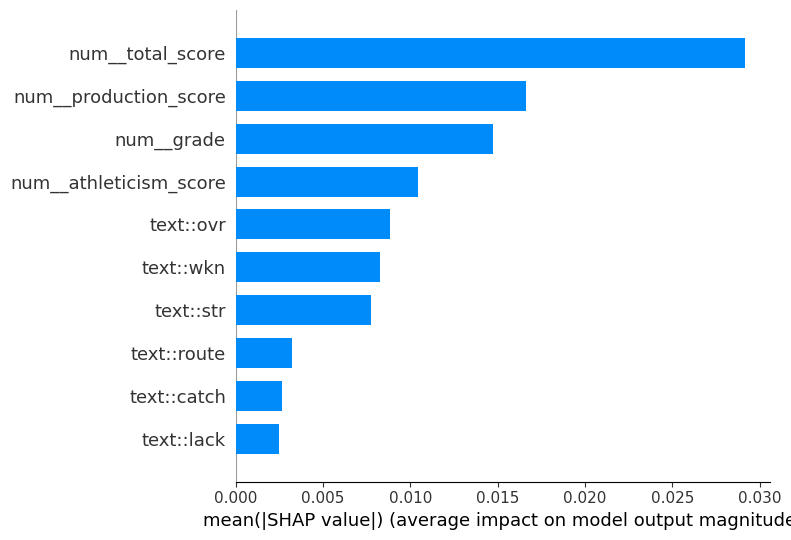

In [19]:
import shap
if subset.empty:
    print('No rows match the filter; skipping SHAP computation')
else:
    focus = subset.head(200)
    preprocessor = pipe.named_steps['features']
    rf = pipe.named_steps['rf']
    background = preprocessor.transform(train_df.sample(min(300, len(train_df)), random_state=0))
    explainer = shap.TreeExplainer(rf, data=background, model_output='probability')
    X_focus = preprocessor.transform(focus)
    shap_values = explainer.shap_values(X_focus)
    if isinstance(shap_values, list):
        shap_positive = shap_values[1]
    elif shap_values.ndim == 3:
        shap_positive = shap_values[..., 1]
    else:
        shap_positive = shap_values
    text_pipe = preprocessor.transformer_list[0][1]
    vectorizer = text_pipe.named_steps['year_norm'].vectorizer
    text_features = [f"text::{term}" for term in vectorizer.get_feature_names_out()]
    meta_transformer = preprocessor.transformer_list[1][1]
    try:
        meta_features = list(meta_transformer.get_feature_names_out())
    except AttributeError:
        meta_features = numeric_features + cat_features
    feature_names = text_features + list(meta_features)
    X_df = pd.DataFrame(X_focus, columns=feature_names)
    mean_abs = np.abs(shap_positive).mean(axis=0)
    feature_importance = (
        pd.DataFrame({'feature': feature_names, 'mean_abs_shap': mean_abs})
        .sort_values('mean_abs_shap', ascending=False)
    )
    print('Top SHAP-contributing features for this slice (bigger values push text_score up)')
    print(feature_importance.head(15).to_string(index=False))
    shap.summary_plot(shap_positive, X_df, feature_names=feature_names, max_display=10, plot_type='bar')


## Contrast: Chandler Jones (boom) vs. Reggie Ragland (bust)

List the text/baseline signals the models relied on for these two edge prospects so you can see why one was right and one was wrong.

In [20]:
players = ['Mike Boone', 'Reggie Ragland']
insights = []
text_pipe = pipe.named_steps['features'].transformer_list[0][1]
year_norm = text_pipe.named_steps['year_norm']
for name in players:
    candidate = df[df['player_name'].str.contains(name, case=False, regex=False)]
    if candidate.empty:
        print(f'No record for {name} (string match failed)')
        continue
    candidate_row = candidate.iloc[0]
    row_df = candidate_row.to_frame().T
    text_vec = year_norm.transform(row_df[['scouting_text_tagged', 'year']])
    text_terms = year_norm.vectorizer.get_feature_names_out()
    term_scores = pd.Series(text_vec.ravel(), index=text_terms).nlargest(8)
    print(f'{name} top text deviations:')
    print(term_scores)
    baseline_input = pd.DataFrame([{ 'grade': candidate_row['grade'], 'Pos_Group': candidate_row['Pos_Group'], 'year': candidate_row['year'] }])
    baseline_preproc = baseline_pipe.named_steps['preproc']
    baseline_values = baseline_preproc.transform(baseline_input).toarray().ravel()
    feature_names = baseline_preproc.get_feature_names_out()
    coef = baseline_pipe.named_steps['lr'].coef_.ravel()
    contrib = pd.Series(coef * baseline_values, index=feature_names).sort_values(ascending=False)
    print(f"{name} baseline contributions (intercept {baseline_pipe.named_steps['lr'].intercept_[0]:.3f}):", contrib.head(6))
    preds = {
        'text_score': pipe.predict_proba(row_df)[:, 1][0],
        'baseline_score': baseline_pipe.predict_proba(baseline_input)[:, 1][0],
    }
    print(f"{name} text/baseline scores:", preds)

Mike Boone top text deviations:
testing          0.229561
explosive        0.144636
running style    0.138427
tremendous       0.131000
run lane         0.130577
tight quarter    0.129205
finesse          0.127695
carry            0.126895
dtype: float64
Mike Boone baseline contributions (intercept -0.758): pos__Pos_Group_DB     -0.0
pos__Pos_Group_DT     -0.0
pos__Pos_Group_EDGE   -0.0
pos__Pos_Group_LB      0.0
pos__Pos_Group_OL      0.0
pos__Pos_Group_QB     -0.0
dtype: float64
Mike Boone text/baseline scores: {'text_score': np.float64(0.715), 'baseline_score': np.float64(0.06704118759894774)}
Reggie Ragland top text deviations:
inside linebacker    0.210943
showed               0.151357
linebacker           0.142753
old                  0.130460
mentality            0.127418
three season         0.124223
question             0.123418
run fit              0.122627
dtype: float64
Reggie Ragland baseline contributions (intercept -0.758): grade__grade           2.227733
pos__Pos_Group_